# Exit Timing Backtest: Buy the Forecast Bucket at 6 AM

**Setup**: At 6 AM local, the ensemble model predicts a daily max temp. We buy YES on the 5°F Kalshi bucket that contains that prediction. Then compare 4 exit strategies:

| Trade | Entry | Exit |
|-------|-------|------|
| Trade 1 | 6 AM | Hold to settlement (end of day) |
| Trade 2 | 6 AM | Sell at 3 PM |
| Trade 3 | 6 AM | Sell at 12 PM |
| Trade 4 | 6 AM | Sell at 9 AM |

**Contract**: Kalshi temp bucket, e.g. "Daily high between 75°F and 80°F". Settles YES if actual high falls in the bucket.

**Pricing**: At each time point, we compute the fair price of the bucket using a Gaussian distribution centered on the best estimate of the daily high (which updates as we observe more of the day's temps).

**Fees**: Kalshi taker fee = ceil(7% × P × (1−P)) on entry and on any early exit.

In [1]:
%matplotlib inline
import sys, os, math, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

import config as cfg
import data_fetch

FEE_RATE = 0.07
BUCKET_WIDTH = 5  # 5°F buckets

def taker_fee(price_cents, contracts=1):
    p = price_cents / 100
    return math.ceil(FEE_RATE * contracts * p * (1 - p) * 100)

def bucket_for_temp(temp):
    """Return (low, high) edges of the 5°F bucket containing temp."""
    low = math.floor(temp / BUCKET_WIDTH) * BUCKET_WIDTH
    return (low, low + BUCKET_WIDTH)

def bucket_prob(mu, sigma, low, high):
    """P(low <= daily_high < high) under N(mu, sigma)."""
    return norm.cdf(high, mu, sigma) - norm.cdf(low, mu, sigma)

def price_cents(prob):
    return max(1, min(99, round(prob * 100)))

print(f'Loaded {len(cfg.CITIES)} cities, bucket width = {BUCKET_WIDTH}°F')

Loaded 20 cities, bucket width = 5°F


## 1. Load Data

In [2]:
daily = data_fetch.load_archive_daily()
daily['date'] = pd.to_datetime(daily['date'])
print(f'Daily: {len(daily):,} rows, {daily.date.min().date()} to {daily.date.max().date()}')

hourly = data_fetch.load_archive_hourly()
hourly['datetime'] = pd.to_datetime(hourly['datetime'])
hourly['date'] = hourly['datetime'].dt.normalize()
hourly['hour'] = hourly['datetime'].dt.hour
print(f'Hourly: {len(hourly):,} rows')

Daily: 31,340 rows, 2022-01-01 to 2026-04-16
Hourly: 752,160 rows


In [3]:
# Running max at key hours (vectorized)
hourly = hourly.sort_values(['ticker', 'date', 'hour']).reset_index(drop=True)
hourly['cummax'] = hourly.groupby(['ticker', 'date'])['temperature_2m'].cummax()

kh = hourly[hourly['hour'].isin([6, 9, 12, 15])].pivot_table(
    index=['ticker', 'date'], columns='hour', values='cummax', aggfunc='first'
).reset_index()
kh.columns.name = None
kh.rename(columns={6: 'rm6', 9: 'rm9', 12: 'rm12', 15: 'rm15'}, inplace=True)

# Merge with daily highs
df = kh.merge(daily[['ticker', 'date', 'temperature_2m_max']], on=['ticker', 'date'], how='inner')
df.rename(columns={'temperature_2m_max': 'actual_high'}, inplace=True)
df = df.dropna().reset_index(drop=True)

# Per-city daily high volatility (for Gaussian sigma)
df = df.sort_values(['ticker', 'date'])
df['high_diff'] = df.groupby('ticker')['actual_high'].diff()
vol = df.groupby('ticker')['high_diff'].std().reset_index(name='daily_vol')
df = df.merge(vol, on='ticker')

print(f'Dataset: {len(df):,} city-days')
df[['ticker', 'date', 'rm6', 'rm9', 'rm12', 'rm15', 'actual_high', 'daily_vol']].head()

Dataset: 31,340 city-days


,ticker,date,rm6,rm9,rm12,rm15,actual_high,daily_vol
0,KXHIGHAUS,2022-01-01,72.2,72.2,75.8,81.1,81.9,6.552265
1,KXHIGHAUS,2022-01-02,39.6,39.6,39.6,44.1,45.1,6.552265
2,KXHIGHAUS,2022-01-03,34.7,34.7,44.7,51.8,52.3,6.552265
3,KXHIGHAUS,2022-01-04,38.9,38.9,51.9,61.1,62.2,6.552265
4,KXHIGHAUS,2022-01-05,51.0,51.0,61.2,68.8,69.4,6.552265


## 2. Pricing Model

At time $t$ during the day, our best estimate of the daily high is:

$$\mu_t = \max(\text{running\_max}_t,\; \text{running\_max}_t + \text{expected\_remaining\_rise})$$

$$\sigma_t = \text{daily\_vol} \times \sqrt{\text{fraction\_of\_day\_remaining}}$$

- **6 AM**: Full day ahead → $\mu$ = running_max + expected rise, $\sigma$ = full daily vol
- **3 PM**: Peak nearly reached → $\mu$ ≈ running_max, $\sigma$ very small
- **Settlement**: Actual known → bucket either pays 100¢ or 0¢

In [4]:
def estimate_daily_high(running_max, hours_remaining, daily_vol):
    """Best estimate of daily high and its uncertainty at a point in the day.
    
    Returns (mu, sigma) for a Gaussian model of the final daily high.
    """
    total_hours = 10.0  # heating from 6am to 4pm
    frac_remaining = max(0.0, hours_remaining / total_hours)
    
    # Expected additional rise: temps typically rise from morning to afternoon
    # The more time left, the more likely the temp hasn't peaked yet
    expected_rise = frac_remaining * daily_vol * 0.8
    mu = running_max + expected_rise
    
    # Uncertainty shrinks as day progresses
    sigma = max(0.5, daily_vol * math.sqrt(frac_remaining))
    
    return mu, sigma

# Quick sanity check
for hr_label, hr_rem in [('6 AM', 10), ('9 AM', 7), ('Noon', 4), ('3 PM', 1)]:
    mu, sig = estimate_daily_high(60.0, hr_rem, 7.0)
    prob = bucket_prob(mu, sig, 65, 70)
    print(f'{hr_label}: mu={mu:.1f}°F, sigma={sig:.1f}°F, P(65-70)={prob:.3f} → {price_cents(prob)}¢')

6 AM: mu=65.6°F, sigma=7.0°F, P(65-70)=0.269 → 27¢
9 AM: mu=63.9°F, sigma=5.9°F, P(65-70)=0.277 → 28¢
Noon: mu=62.2°F, sigma=4.4°F, P(65-70)=0.227 → 23¢
3 PM: mu=60.6°F, sigma=2.2°F, P(65-70)=0.022 → 2¢


## 3. Simulate Trades

In [5]:
results = []

for _, row in df.iterrows():
    dvol = row['daily_vol']
    actual = row['actual_high']
    
    # At 6 AM: estimate daily high and pick the bucket
    mu6, sig6 = estimate_daily_high(row['rm6'], hours_remaining=10, daily_vol=dvol)
    bkt_low, bkt_high = bucket_for_temp(mu6)  # bucket containing our forecast
    
    # Entry price at 6 AM
    p6 = bucket_prob(mu6, sig6, bkt_low, bkt_high)
    entry = price_cents(p6)
    if entry < 5 or entry > 95:  # skip extreme prices (no liquidity)
        continue
    entry_fee = taker_fee(entry)
    
    # Exit prices at 9 AM, noon, 3 PM (updated estimate of daily high)
    mu9, sig9 = estimate_daily_high(row['rm9'], 7, dvol)
    mu12, sig12 = estimate_daily_high(row['rm12'], 4, dvol)
    mu15, sig15 = estimate_daily_high(row['rm15'], 1, dvol)
    
    exit9 = price_cents(bucket_prob(mu9, sig9, bkt_low, bkt_high))
    exit12 = price_cents(bucket_prob(mu12, sig12, bkt_low, bkt_high))
    exit15 = price_cents(bucket_prob(mu15, sig15, bkt_low, bkt_high))
    
    # Settlement: YES = 100¢ if actual high is in the bucket
    settled = 1 if bkt_low <= actual < bkt_high else 0
    payout = 100 * settled
    
    # P&L (cents per contract)
    pnl_hold = payout - entry - entry_fee
    pnl_3pm  = exit15 - entry - entry_fee - taker_fee(exit15)
    pnl_noon = exit12 - entry - entry_fee - taker_fee(exit12)
    pnl_9am  = exit9  - entry - entry_fee - taker_fee(exit9)
    
    results.append({
        'ticker': row['ticker'], 'date': row['date'],
        'actual_high': actual, 'bucket': f'{bkt_low}-{bkt_high}',
        'bkt_low': bkt_low, 'bkt_high': bkt_high,
        'mu6': mu6, 'sig6': sig6,
        'entry': entry, 'entry_fee': entry_fee,
        'exit9': exit9, 'exit12': exit12, 'exit15': exit15,
        'settled': settled, 'payout': payout,
        'pnl_hold': pnl_hold, 'pnl_3pm': pnl_3pm,
        'pnl_noon': pnl_noon, 'pnl_9am': pnl_9am,
    })

trades = pd.DataFrame(results)
trades['date'] = pd.to_datetime(trades['date'])
trades['city'] = trades['ticker'].map(lambda t: cfg.CITIES.get(t, (t,))[0])

print(f'Trades: {len(trades):,}')
print(f'Period: {trades.date.min().date()} to {trades.date.max().date()}')
print(f'Avg entry: {trades.entry.mean():.1f}¢ | Settle YES rate: {trades.settled.mean()*100:.1f}%')
trades.head(8)

Trades: 31,340
Period: 2022-01-01 to 2026-04-16
Avg entry: 31.3¢ | Settle YES rate: 15.7%


,ticker,date,actual_high,bucket,bkt_low,bkt_high,mu6,sig6,entry,entry_fee,exit9,exit12,exit15,settled,payout,pnl_hold,pnl_3pm,pnl_noon,pnl_9am,city
0,KXHIGHAUS,2022-01-01,81.9,75-80,75,80,77.441812,6.552265,30,2,34,45,22,0,0,-32,-12,11,0,Austin
1,KXHIGHAUS,2022-01-02,45.1,40-45,40,45,44.841812,6.552265,28,2,35,45,56,0,0,-30,24,13,3,Austin
2,KXHIGHAUS,2022-01-03,52.3,35-40,35,40,39.941812,6.552265,28,2,35,5,1,0,0,-30,-30,-26,3,Austin
3,KXHIGHAUS,2022-01-04,62.2,40-45,40,45,44.141812,6.552265,29,2,35,1,1,0,0,-31,-31,-31,2,Austin
4,KXHIGHAUS,2022-01-05,69.4,55-60,55,60,56.241812,6.552265,29,2,31,19,1,0,0,-31,-31,-14,-2,Austin
5,KXHIGHAUS,2022-01-06,55.1,50-55,50,55,52.741812,6.552265,30,2,34,34,38,0,0,-32,4,0,0,Austin
6,KXHIGHAUS,2022-01-07,52.0,40-45,40,45,40.241812,6.552265,28,2,28,44,1,0,0,-30,-30,12,-4,Austin
7,KXHIGHAUS,2022-01-08,64.8,50-55,50,55,52.941812,6.552265,30,2,30,4,1,0,0,-32,-32,-29,-4,Austin


## 4. Strategy Comparison

In [6]:
def summarize(pnl, name):
    n = len(pnl)
    tot = pnl.sum()
    mu = pnl.mean()
    sd = pnl.std()
    wr = (pnl > 0).mean() * 100
    sharpe = mu / sd * math.sqrt(252) if sd > 0 else 0
    dd = (pnl.cumsum() - pnl.cumsum().cummax()).min()
    return {'Strategy': name, 'Trades': n,
            'Total P&L ($)': round(tot / 100, 2),
            'Mean (¢)': round(mu, 2), 'Std (¢)': round(sd, 2),
            'Win %': round(wr, 1), 'Sharpe': round(sharpe, 2),
            'Max DD (¢)': round(dd)}

summary = pd.DataFrame([
    summarize(trades['pnl_hold'], 'Trade 1: Hold to Settlement'),
    summarize(trades['pnl_3pm'],  'Trade 2: Sell at 3 PM'),
    summarize(trades['pnl_noon'], 'Trade 3: Sell at Noon'),
    summarize(trades['pnl_9am'],  'Trade 4: Sell at 9 AM'),
])
display(summary.set_index('Strategy'))

,Trades,Total P&L ($),Mean (¢),Std (¢),Win %,Sharpe,Max DD (¢)
Strategy,,,,,,,
Trade 1: Hold to Settlement,31340,-5516.91,-17.60,37.22,15.7,-7.51,-551776
Trade 2: Sell at 3 PM,31340,-5482.62,-17.49,26.21,22.1,-10.60,-548326
Trade 3: Sell at Noon,31340,-3596.46,-11.48,18.70,34.6,-9.74,-359723
Trade 4: Sell at 9 AM,31340,-370.23,-1.18,5.81,41.1,-3.23,-37563


## 5. Cumulative P&L

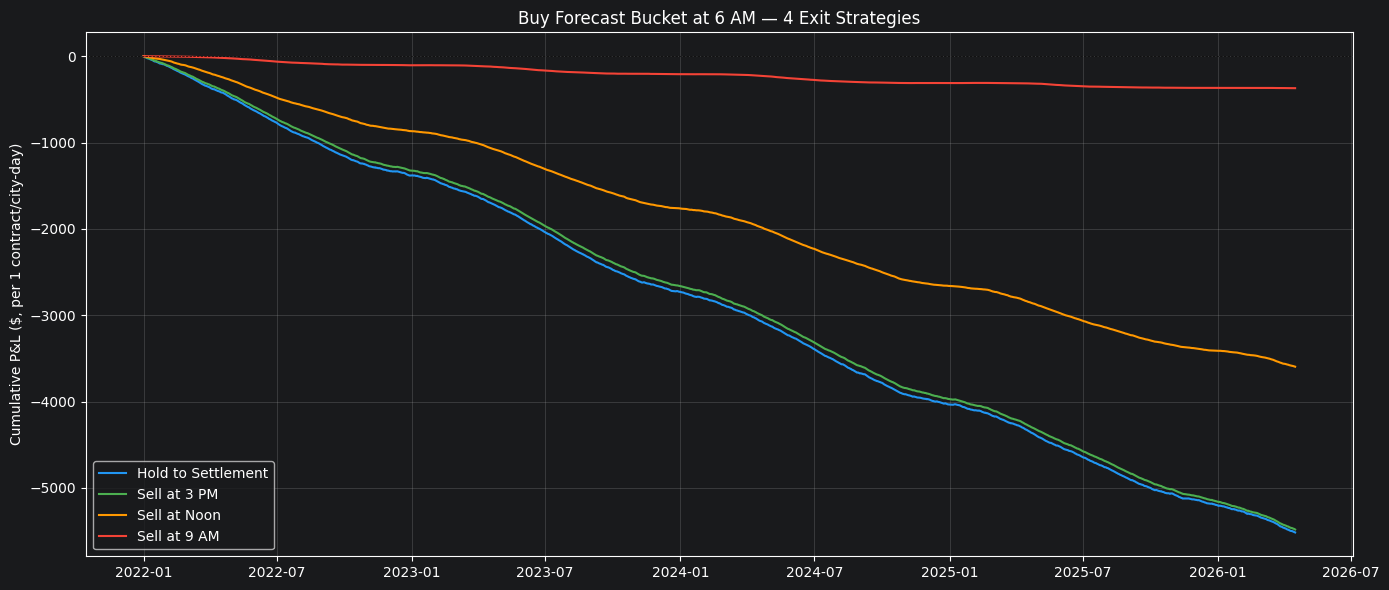

In [7]:
daily_pnl = trades.groupby('date')[['pnl_hold','pnl_3pm','pnl_noon','pnl_9am']].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
for col, lbl, c in [
    ('pnl_hold', 'Hold to Settlement', '#2196F3'),
    ('pnl_3pm',  'Sell at 3 PM',       '#4CAF50'),
    ('pnl_noon', 'Sell at Noon',        '#FF9800'),
    ('pnl_9am',  'Sell at 9 AM',        '#F44336'),
]:
    ax.plot(daily_pnl['date'], daily_pnl[col].cumsum() / 100, label=lbl, linewidth=1.5, color=c)
ax.set_ylabel('Cumulative P&L ($, per 1 contract/city-day)')
ax.set_title('Buy Forecast Bucket at 6 AM — 4 Exit Strategies')
ax.legend(); ax.axhline(0, color='k', lw=0.5, ls='--'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. P&L by City

,city,n,hold,sell3,sell12,sell9,win_hold,settle_rate
3,Chicago,1567,10.91,-10.37,-20.39,-22.59,24.377792,0.243778
2,Boston,1567,-44.74,-85.45,-82.95,-26.74,22.910019,0.229100
17,San Francisco,1567,-87.19,-130.17,-100.25,2.03,34.588385,0.345884
10,Minneapolis,1567,-124.76,-122.69,-66.92,-19.36,16.975112,0.169751
12,New York,1567,-137.37,-134.74,-98.32,-20.73,18.953414,0.189534
19,Washington DC,1567,-176.08,-180.81,-105.61,-13.97,16.975112,0.169751
14,Philadelphia,1567,-181.69,-186.62,-124.84,-20.83,17.038928,0.170389
13,Oklahoma City,1567,-186.26,-168.83,-45.66,-13.43,14.613912,0.146139
11,New Orleans,1567,-193.40,-185.60,-125.57,-17.25,23.484365,0.234844
18,Seattle,1567,-224.17,-233.79,-110.92,-3.40,28.079132,0.280791


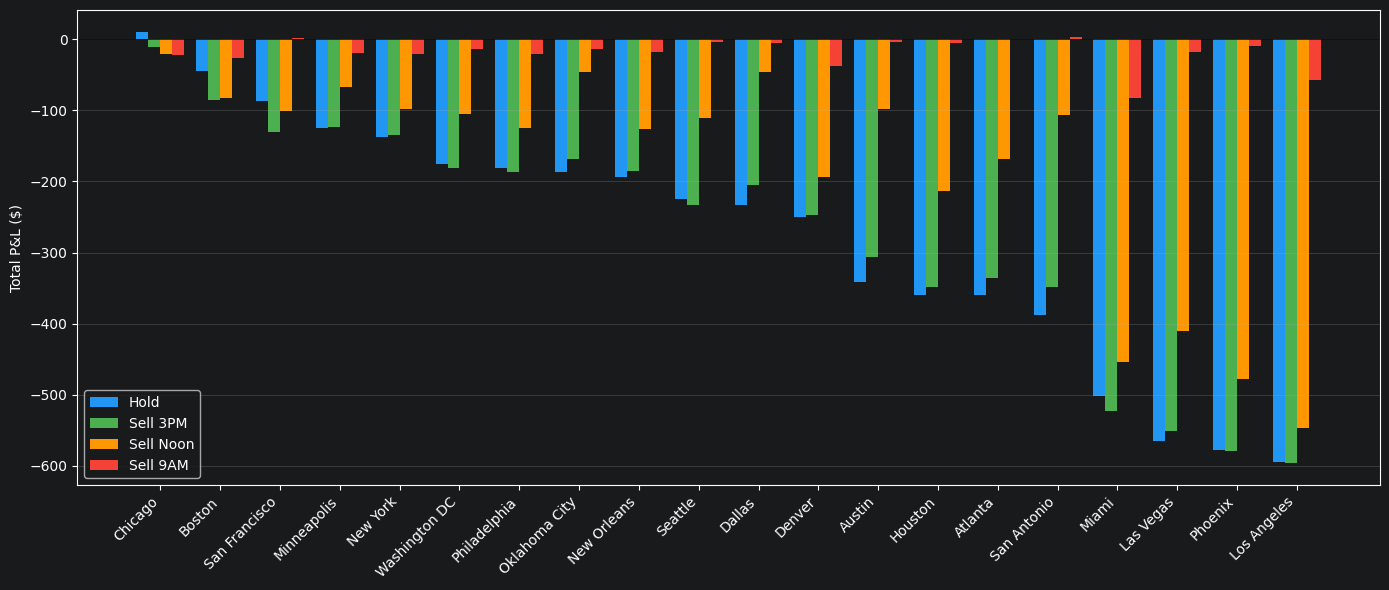

In [8]:
cp = trades.groupby('city').agg(
    n=('pnl_hold','count'),
    hold=('pnl_hold','sum'), sell3=('pnl_3pm','sum'),
    sell12=('pnl_noon','sum'), sell9=('pnl_9am','sum'),
    win_hold=('pnl_hold', lambda x: (x>0).mean()*100),
    settle_rate=('settled','mean'),
).reset_index()
for c in ['hold','sell3','sell12','sell9']: cp[c] = (cp[c]/100).round(2)
cp = cp.sort_values('hold', ascending=False)
display(cp)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(cp)); w = 0.2
ax.bar(x-1.5*w, cp['hold'], w, label='Hold', color='#2196F3')
ax.bar(x-0.5*w, cp['sell3'], w, label='Sell 3PM', color='#4CAF50')
ax.bar(x+0.5*w, cp['sell12'], w, label='Sell Noon', color='#FF9800')
ax.bar(x+1.5*w, cp['sell9'], w, label='Sell 9AM', color='#F44336')
ax.set_xticks(x); ax.set_xticklabels(cp['city'], rotation=45, ha='right')
ax.set_ylabel('Total P&L ($)'); ax.legend(); ax.axhline(0, color='k', lw=0.5)
ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

## 7. Price Path Through the Day

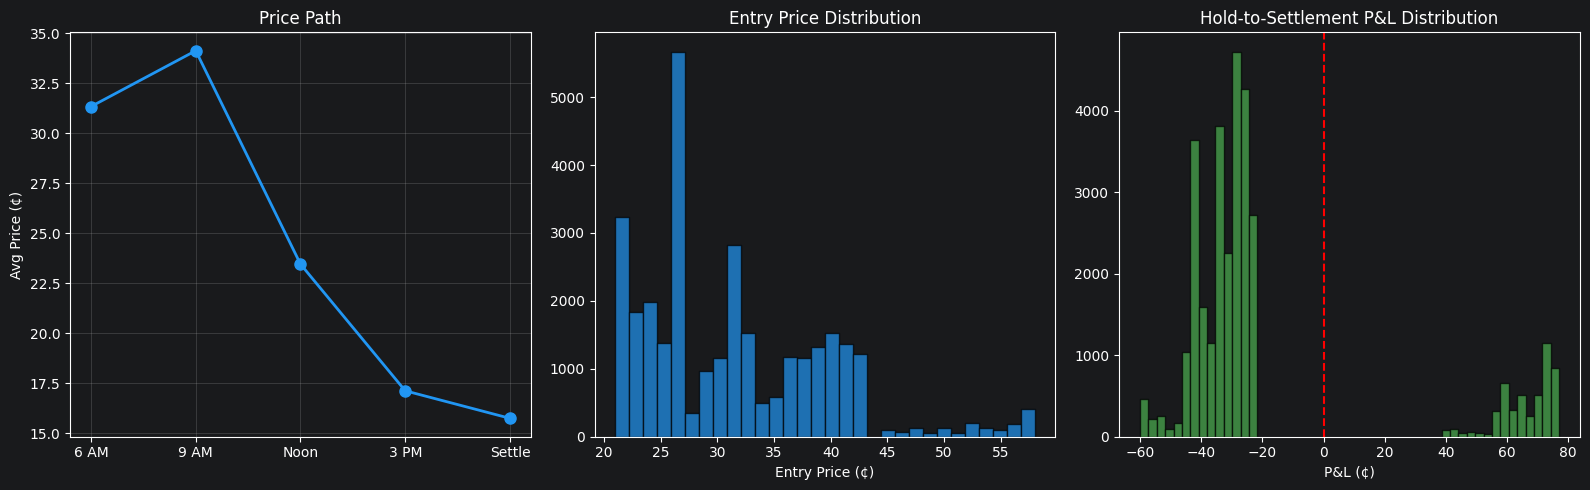

,Time,Avg Price (¢)
0,6 AM,31.337301
1,9 AM,34.132163
2,Noon,23.451021
3,3 PM,17.112093
4,Settle,15.733886


In [9]:
avg = pd.DataFrame({
    'Time': ['6 AM', '9 AM', 'Noon', '3 PM', 'Settle'],
    'Avg Price (¢)': [trades.entry.mean(), trades.exit9.mean(),
                      trades.exit12.mean(), trades.exit15.mean(),
                      trades.payout.mean()],
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(avg['Time'], avg['Avg Price (¢)'], 'o-', lw=2, ms=8, color='#2196F3')
axes[0].set_ylabel('Avg Price (¢)'); axes[0].set_title('Price Path'); axes[0].grid(alpha=0.3)

axes[1].hist(trades['entry'], bins=30, edgecolor='k', alpha=0.7, color='#2196F3')
axes[1].set_xlabel('Entry Price (¢)'); axes[1].set_title('Entry Price Distribution')

axes[2].hist(trades['pnl_hold'], bins=50, edgecolor='k', alpha=0.7, color='#4CAF50')
axes[2].axvline(0, color='r', ls='--')
axes[2].set_xlabel('P&L (¢)'); axes[2].set_title('Hold-to-Settlement P&L Distribution')

plt.tight_layout(); plt.show()
display(avg)

## 8. Monthly P&L

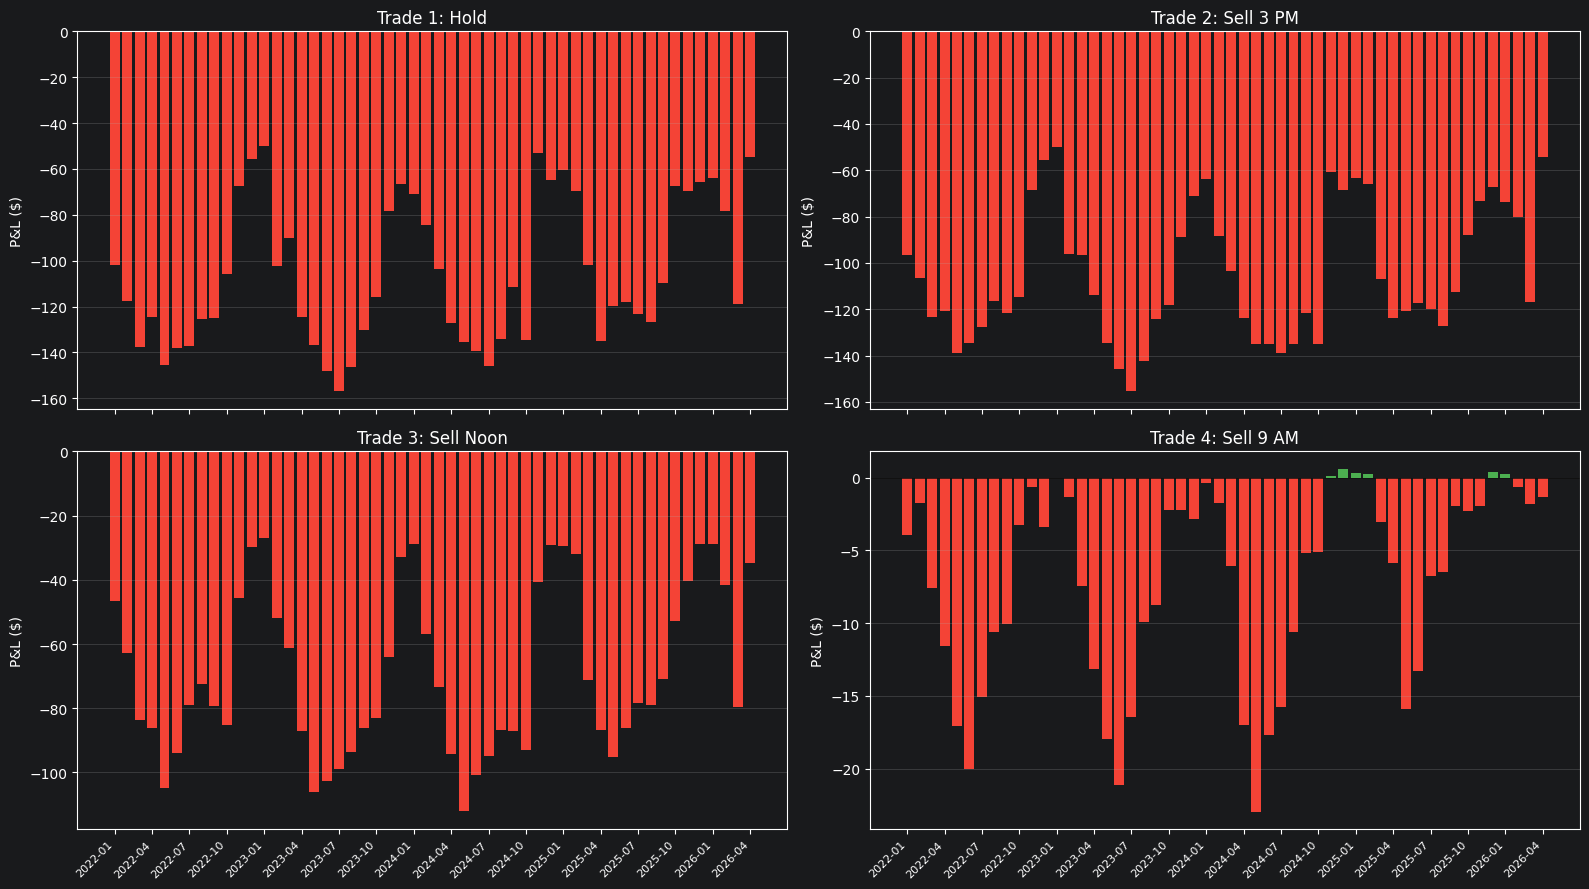

In [10]:
trades['ym'] = trades['date'].dt.to_period('M').astype(str)
mo = trades.groupby('ym')[['pnl_hold','pnl_3pm','pnl_noon','pnl_9am']].sum().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)
for ax, (col, title) in zip(axes.flat, [
    ('pnl_hold', 'Trade 1: Hold'), ('pnl_3pm', 'Trade 2: Sell 3 PM'),
    ('pnl_noon', 'Trade 3: Sell Noon'), ('pnl_9am', 'Trade 4: Sell 9 AM'),
]):
    colors = ['#F44336' if v < 0 else '#4CAF50' for v in mo[col]]
    ax.bar(range(len(mo)), mo[col]/100, color=colors)
    ax.set_xticks(range(0, len(mo), 3))
    ax.set_xticklabels(mo['ym'].iloc[::3], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('P&L ($)'); ax.set_title(title)
    ax.axhline(0, color='k', lw=0.5); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Fee Impact

In [11]:
fee_df = pd.DataFrame({
    'Strategy': ['Hold', 'Sell 3 PM', 'Sell Noon', 'Sell 9 AM'],
    'Gross (¢)': [
        (trades.payout - trades.entry).mean(),
        (trades.exit15 - trades.entry).mean(),
        (trades.exit12 - trades.entry).mean(),
        (trades.exit9 - trades.entry).mean(),
    ],
    'Net (¢)': [trades.pnl_hold.mean(), trades.pnl_3pm.mean(),
               trades.pnl_noon.mean(), trades.pnl_9am.mean()],
})
fee_df['Fee Drag (¢)'] = fee_df['Gross (¢)'] - fee_df['Net (¢)']
fee_df['Fees as % of |Gross|'] = (fee_df['Fee Drag (¢)'] / fee_df['Gross (¢)'].abs() * 100).round(1)
display(fee_df.round(2).set_index('Strategy'))

,Gross (¢),Net (¢),Fee Drag (¢),Fees as % of |Gross|
Strategy,,,,
Hold,-15.60,-17.60,2.00,12.8
Sell 3 PM,-14.23,-17.49,3.27,23.0
Sell Noon,-7.89,-11.48,3.59,45.5
Sell 9 AM,2.79,-1.18,3.98,142.3


## 10. Summary

In [12]:
print('='*70)
print(f'  BACKTEST: Buy forecast bucket at 6 AM | {trades.date.min().date()} to {trades.date.max().date()}')
print(f'  {len(trades):,} trades across {trades.ticker.nunique()} cities')
print(f'  Avg entry: {trades.entry.mean():.1f}¢ | Bucket settles YES: {trades.settled.mean()*100:.1f}%')
print('='*70)
for lbl, col in [('Hold to Settlement', 'pnl_hold'), ('Sell at 3 PM', 'pnl_3pm'),
                  ('Sell at Noon', 'pnl_noon'), ('Sell at 9 AM', 'pnl_9am')]:
    p = trades[col]
    sh = p.mean() / p.std() * math.sqrt(252) if p.std() > 0 else 0
    print(f'  {lbl:<22s}  Total: ${p.sum()/100:>9.2f}  '
          f'Mean: {p.mean():>6.2f}¢  Win: {(p>0).mean()*100:>5.1f}%  Sharpe: {sh:>5.2f}')

  BACKTEST: Buy forecast bucket at 6 AM | 2022-01-01 to 2026-04-16
  31,340 trades across 20 cities
  Avg entry: 31.3¢ | Bucket settles YES: 15.7%
  Hold to Settlement      Total: $ -5516.91  Mean: -17.60¢  Win:  15.7%  Sharpe: -7.51
  Sell at 3 PM            Total: $ -5482.62  Mean: -17.49¢  Win:  22.1%  Sharpe: -10.60
  Sell at Noon            Total: $ -3596.46  Mean: -11.48¢  Win:  34.6%  Sharpe: -9.74
  Sell at 9 AM            Total: $  -370.23  Mean:  -1.18¢  Win:  41.1%  Sharpe: -3.23
